# 10 — Engagement Analytics

**Day 3, Step 10.** No ML — aggregation, as the Build Notes specify.

Two corrections carried in from the audit: aggregate on **employee grain** (F5),
and remember the scale is **1–5**, not 0–100 (F6).

In [1]:
import sys, warnings
sys.path.insert(0, "../src"); sys.path.insert(0, "..")
warnings.filterwarnings("ignore")

import pandas as pd, numpy as np, matplotlib.pyplot as plt
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

# The lab imports from the factory. Nothing below reimplements pipeline logic.
from hrai.utils.config import get, raw_path, seed
from hrai.utils.io import load_raw, load_processed
from hrai.utils.logger import setup_logging
setup_logging(fmt="human")
print(f"seed={seed()}  |  datasets: {sorted(get('datasets'))}")

seed=42  |  datasets: ['employee_attrition', 'essential_skills', 'hr_performance_engagement', 'occupation_data', 'software_skills']


In [2]:
from hrai.intelligence.engagement import (engagement_summary, engagement_by,
                                          lowest_engagement, training_effectiveness)
pd.Series(engagement_summary())

employees                          3000
average_engagement                 2.94
average_engagement_pct             58.8
average_satisfaction               3.02
average_work_life_balance          2.99
scale                        1-5 Likert
voluntary_exit_rate               0.107
low_engagement_employees           1273
dtype: object

,DepartmentType,employees,avg_engagement,avg_satisfaction,avg_work_life_balance,voluntary_exit_rate,low_engagement
0,Production,2020,2.906,3.021,2.962,0.142,885
1,Admin Offices,80,2.925,2.512,3.188,0.012,37
2,Software Engineering,115,2.974,3.113,3.009,0.174,42
3,Sales,331,2.991,3.133,3.06,0.030,133
4,IT/IS,430,3.026,3.009,3.002,0.007,170
5,Executive Office,24,3.375,3.083,3.292,0.000,6


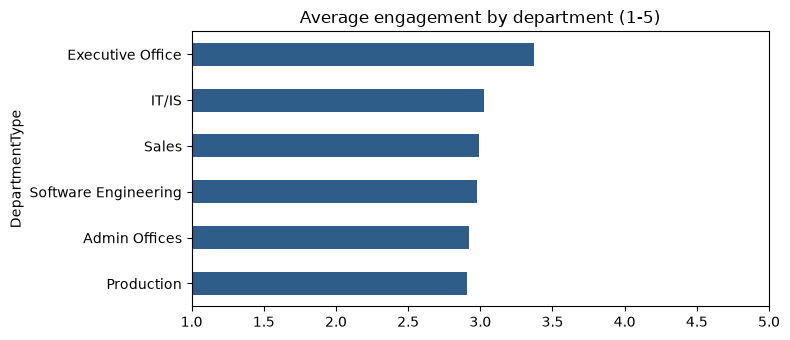

In [3]:
by_dept = engagement_by("DepartmentType")
ax = by_dept.set_index("DepartmentType")["avg_engagement"].plot(
    kind="barh", figsize=(8, 3.5), color="#2F5D8A",
    title="Average engagement by department (1-5)")
ax.set_xlim(1, 5); plt.tight_layout()
by_dept

In [4]:
engagement_by("tenure_band")

,tenure_band,employees,avg_engagement,avg_satisfaction,avg_work_life_balance,voluntary_exit_rate,low_engagement
0,<1y,341,2.821,3.082,2.856,0.070,150
1,5-10y,248,2.895,3.081,2.855,0.133,104
2,1-3y,1221,2.919,3.032,3.048,0.104,523
3,3-5y,1190,3.004,2.982,2.994,0.115,496


## The employees HR should look at directly

In [5]:
lowest_engagement(15)

,employee_id,Title,DepartmentType,Division,tenure_years,engagement_score,satisfaction_score,work_life_balance_score,current_employee_rating,training_pass_rate,EmployeeStatus
0,1015,Shared Services Manager,Software Engineering,People Services,5.08,1,1,3,3,1.0,Active
1,1043,Shared Services Manager,Software Engineering,Splicing,1.03,1,1,3,3,1.0,Active
2,1086,Software Engineer,Software Engineering,Field Operations,1.39,1,1,5,3,1.0,Active
3,1101,Production Technician I,Production,Engineers,2.81,1,1,3,3,1.0,Active
4,1110,Production Technician II,Production,General - Con,1.50,1,1,4,3,1.0,Active
5,1121,Production Manager,Production,Aerial,2.79,1,1,4,3,0.0,Active
6,1129,Production Technician II,Production,Field Operations,4.28,1,1,1,3,1.0,Voluntarily Terminated
7,1152,Production Technician I,Production,Engineers,0.97,1,1,5,3,0.0,Active
8,1296,Production Technician II,Production,Field Operations,4.80,1,1,5,3,1.0,Voluntarily Terminated
9,1309,Production Technician I,Production,Field Operations,3.37,1,1,3,3,0.0,Active


## Does training actually move engagement?

Using the real training records, including outcome — which matters, because a
failed course is not the same intervention as a passed one.

In [6]:
training_effectiveness().head(10)

,Training Program Name,Training Outcome,events,avg_engagement,avg_cost,avg_days
0,Communication Skills,Completed,203,2.88,541.77,2.89
1,Communication Skills,Failed,153,2.92,559.16,3.05
2,Communication Skills,Incomplete,171,3.09,528.39,2.77
3,Communication Skills,Passed,178,2.76,545.14,3.12
4,Customer Service,Completed,170,2.95,582.34,2.96
5,Customer Service,Failed,142,3.09,563.66,2.89
6,Customer Service,Incomplete,139,2.81,537.53,2.85
7,Customer Service,Passed,143,2.9,575.21,3.10
8,Leadership Development,Completed,147,3.0,542.24,2.95
9,Leadership Development,Failed,132,2.81,558.84,3.26
